# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

### Step 1. Load the data

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv")

In [3]:
df.head()


,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X=df[['Experience Years']]
y=df['Salary']

### Step 2.b print the type of each

In [5]:
print(f'X: {X.dtypes}')
print(f'y: {y.dtype}')

X: Experience Years    float64
dtype: object
y: int64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Answer: Target is numerical and the task is regression 

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print(X.shape[0])
print(y.shape[0])

40
40


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

Text(0.5, 1.0, 'Feature vs Target Scatter plot')

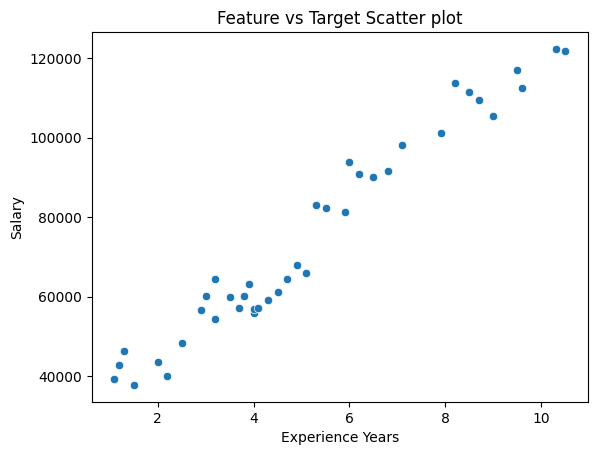

In [8]:
sns.scatterplot(data=df, x=df['Experience Years'],y= df['Salary'])
plt.title("Feature vs Target Scatter plot")

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [9]:
corr = df['Experience Years'].corr(df['Salary'])
print(corr)


0.9776918968570498


There is high correlation between the two variables with a correlation of `0.97`

### Step 7. Initialize a regression model

In [10]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [11]:
X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Step 9.a Train the model on the training set

In [14]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [17]:
intercept = model.intercept_
slope= model.coef_
print(f'intercept: {intercept:.2f}')
print(f'Slope : {slope[0]:.2f}')

intercept: 26716.25
Slope : 9408.03


### Step 9.c how much salary does a person get with 2 years of experience?

In [23]:
answer=model.predict([[2]])
print(f'Salary for 2 years of experience is {answer[0]}')

Salary for 2 years of experience is 45532.312721158705


/Users/turkialomran/Desktop/SDAIA_Bootcamp/AAI/AAI/content/W3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [ ]:
print(slope*0.5)


[4704.01563625]


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [34]:
print(model.predict([[0]]))
#or 
print(intercept)

[26716.25017615]
26716.25017614555


/Users/turkialomran/Desktop/SDAIA_Bootcamp/AAI/AAI/content/W3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 10. Evaluate the model on the test set

In [32]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
r2=model.score(X_test,y_test)

print(f'Mean absolute error is {mae:.2f}')
print(f'R2 score is : {r2:.2f}')



Mean absolute error is 6419.91
R2 score is : 0.91


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

### Step 12. Plot the data and the regression line